In [ ]:
!pip install 'numpy<2.0' --quiet
!pip install ultralytics==8.3.0 --quiet
!pip install deep_sort_realtime --quiet
!pip install scipy --quiet

# Restart runtime after this cell — Runtime > Restart session
# Then run from the next cell onward. Do NOT re-run this cell.
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


{'status': 'ok', 'restart': True}

In [ ]:
import sys
import types
import json
import csv
import time
import logging
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# deep_sort_realtime needs pkg_resources (part of setuptools).
# Colab's Python 3.12 doesn't ship it — patch before importing.
_stub = types.ModuleType('pkg_resources')
def _resource_filename(package, resource):
    import os
    base = '/usr/local/lib/python3.12/dist-packages/deep_sort_realtime'
    return os.path.join(base, resource)
_stub.resource_filename = _resource_filename
sys.modules.setdefault('pkg_resources', _stub)

from deep_sort_realtime.deepsort_tracker import DeepSort
from ultralytics import YOLO

logging.getLogger('ultralytics').setLevel(logging.WARNING)
print('Imports OK.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR  = Path('/content/drive/MyDrive/shoplens')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = Path('/content/mall_dataset')
FRAMES_DIR  = DATASET_DIR / 'frames'
GT_PATH     = DATASET_DIR / 'mall_gt.mat'
DRIVE_ZIP   = Path('/content/drive/MyDrive/datasets/mall_dataset.zip')

# Extract dataset if not already done
import zipfile
if not (FRAMES_DIR.exists() and len(list(FRAMES_DIR.glob('*.jpg'))) == 2000):
    print('Extracting dataset...')
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
        z.extractall('/content/')

assert len(list(FRAMES_DIR.glob('*.jpg'))) == 2000
print('Dataset ready.')

Mounted at /content/drive
Extracting dataset...
Dataset ready.


In [ ]:
def load_ground_truth(mat_path: Path):
    mat = scipy.io.loadmat(mat_path)
    gt_counts = mat['count'].flatten().astype(int)
    frames_raw = mat['frame'].flatten()
    gt_locations = np.empty(len(frames_raw), dtype=object)
    for i, entry in enumerate(frames_raw):
        gt_locations[i] = entry[0][0][0]  # (N, 2) head positions
    return gt_counts, gt_locations


def frame_path(idx: int) -> Path:
    return FRAMES_DIR / f'seq_{idx:06d}.jpg'


gt_counts, gt_locations = load_ground_truth(GT_PATH)
model = YOLO('yolov8n.pt')

# Best threshold from Epic 1
BEST_CONF = 0.1

print(f'GT loaded: {len(gt_counts)} frames')
print(f'Model loaded. Using conf={BEST_CONF} from Epic 1.')

100%|██████████| 6.25M/6.25M [00:00<00:00, 84.7MB/s]


GT loaded: 2000 frames
Model loaded. Using conf=0.1 from Epic 1.


In [ ]:
def detect_persons(img_path: Path, conf: float = BEST_CONF):
    """
    Returns:
        detections_for_tracker: list of ([x1, y1, w, h], conf, 'person')
        boxes_xyxy: (N, 4) array for visualization
        confidences: (N,) array
    """
    results = model(str(img_path), classes=[0], conf=conf, verbose=False, device='cpu')
    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        return [], np.empty((0, 4)), np.empty((0,))

    xyxy  = boxes.xyxy.cpu().numpy()   # (N, 4)
    confs = boxes.conf.cpu().numpy()   # (N,)

    detections_for_tracker = []
    for (x1, y1, x2, y2), c in zip(xyxy, confs):
        w = float(x2 - x1)
        h = float(y2 - y1)
        detections_for_tracker.append(([float(x1), float(y1), w, h], float(c), 'person'))

    return detections_for_tracker, xyxy, confs

In [ ]:
def make_tracker(max_age: int = 30, n_init: int = 3) -> DeepSort:
    """
    max_age  — frames a track survives without a matching detection before deletion.
               Higher = fewer ID switches but more ghost tracks.
    n_init   — frames a detection must appear before becoming a confirmed track.
               Higher = fewer false tracks but slower to confirm real people.
    """
    return DeepSort(
        max_age=max_age,
        n_init=n_init,
        embedder_gpu=False,   # CPU only
        half=False,
    )


tracker = make_tracker(max_age=30, n_init=3)
print('Tracker initialised: max_age=30, n_init=3')

Tracker initialised: max_age=30, n_init=3


In [ ]:
# Run detector + tracker on 10 consecutive frames
TEST_FRAMES = list(range(1, 11))
tracker_smoke = make_tracker()

print(f'{"Frame":<8} {"Detected":<12} {"Active tracks":<16} {"Confirmed tracks"}')
print('-' * 55)

for idx in TEST_FRAMES:
    dets, _, _ = detect_persons(frame_path(idx))
    img = cv2.imread(str(frame_path(idx)))
    tracks = tracker_smoke.update_tracks(dets, frame=img)
    confirmed = [t for t in tracks if t.is_confirmed()]
    print(f'{idx:<8} {len(dets):<12} {len(tracks):<16} {len(confirmed)}')

Frame    Detected     Active tracks    Confirmed tracks
-------------------------------------------------------
1        31           31               0
2        31           31               0
3        32           32               8
4        31           31               10
5        29           32               12
6        25           29               13
7        24           30               15
8        22           31               17
9        22           32               23
10       30           44               25


In [ ]:
def run_tracking_pipeline(frame_indices: list, tracker: DeepSort) -> dict:
    """
    Run YOLOv8 + DeepSORT on a sequence of frames.

    Returns:
        trajectories : dict[track_id -> list of (frame_idx, cx, cy)]
        frame_data   : dict[frame_idx -> list of (track_id, x1, y1, x2, y2)]
        id_switches  : count of times a confirmed track re-appears with a new ID
                       (approximated as tracks confirmed then lost then new ID appears)
    """
    trajectories = defaultdict(list)   # track_id -> [(frame_idx, cx, cy), ...]
    frame_data   = {}                  # frame_idx -> [(track_id, x1, y1, x2, y2), ...]
    all_ids_seen = set()
    total = len(frame_indices)

    for i, idx in enumerate(frame_indices):
        dets, _, _ = detect_persons(frame_path(idx))
        img = cv2.imread(str(frame_path(idx)))
        tracks = tracker.update_tracks(dets, frame=img)

        frame_data[idx] = []
        for t in tracks:
            if not t.is_confirmed():
                continue
            tid = t.track_id
            x1, y1, x2, y2 = t.to_ltrb()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            trajectories[tid].append((idx, float(cx), float(cy)))
            frame_data[idx].append((tid, float(x1), float(y1), float(x2), float(y2)))
            all_ids_seen.add(tid)

        if (i + 1) % 50 == 0 or (i + 1) == total:
            print(f'  [{i + 1:4d}/{total}] frame {idx:4d} | unique IDs so far: {len(all_ids_seen)}')

    return dict(trajectories), frame_data, len(all_ids_seen)

In [ ]:
tracker_200 = make_tracker(max_age=30, n_init=3)
FRAMES_200 = list(range(1, 201))

print(f'Running on {len(FRAMES_200)} frames...')
t0 = time.time()
trajectories_200, frame_data_200, unique_ids_200 = run_tracking_pipeline(FRAMES_200, tracker_200)

print(f'\nDone in {time.time() - t0:.1f}s')
print(f'Unique track IDs assigned: {unique_ids_200}')
print(f'Active trajectories:       {len(trajectories_200)}')

# Track length distribution
lengths = [len(v) for v in trajectories_200.values()]
print(f'Track length — min: {min(lengths)}, max: {max(lengths)}, mean: {np.mean(lengths):.1f}')

Running on 200 frames...
  [  50/200] frame   50 | unique IDs so far: 90
  [ 100/200] frame  100 | unique IDs so far: 121
  [ 150/200] frame  150 | unique IDs so far: 173
  [ 200/200] frame  200 | unique IDs so far: 208

Done in 263.4s
Unique track IDs assigned: 208
Active trajectories:       208
Track length — min: 1, max: 198, mean: 58.2


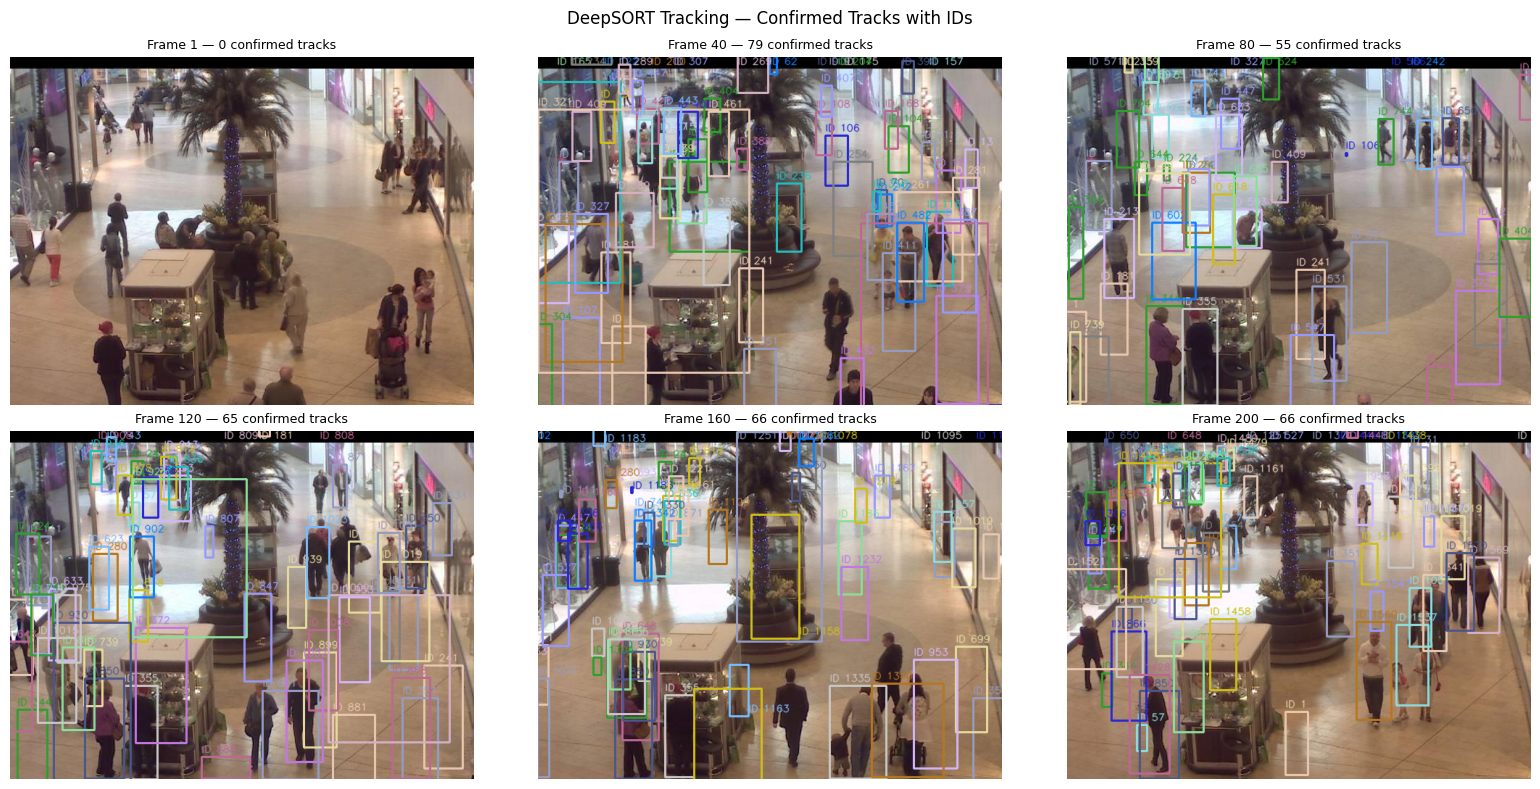

Saved: tracking_sample_frames.png


In [ ]:
def draw_tracked_frame(frame_idx: int, frame_data: dict) -> np.ndarray:
    img = cv2.imread(str(frame_path(frame_idx)))
    for tid, x1, y1, x2, y2 in frame_data.get(frame_idx, []):
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        rgba = plt.cm.tab20(int(tid) % 20)
        colour = (int(rgba[0] * 255), int(rgba[1] * 255), int(rgba[2] * 255))
        cv2.rectangle(img, (x1, y1), (x2, y2), colour, 2)
        cv2.putText(img, f'ID {tid}', (x1, max(y1 - 6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, colour, 1, cv2.LINE_AA)
    return img


sample_vis = [1, 40, 80, 120, 160, 200]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, idx in zip(axes.flatten(), sample_vis):
    ann = draw_tracked_frame(idx, frame_data_200)
    ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    n_tracks = len(frame_data_200.get(idx, []))
    ax.set_title(f'Frame {idx} — {n_tracks} confirmed tracks', fontsize=9)
    ax.axis('off')

plt.suptitle('DeepSORT Tracking — Confirmed Tracks with IDs', fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE_DIR / 'tracking_sample_frames.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: tracking_sample_frames.png')

In [ ]:
VIDEO_OUT = DRIVE_DIR / 'tracking_annotated.mp4'

# Read frame size from first frame
sample_img = cv2.imread(str(frame_path(1)))
h, w = sample_img.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(VIDEO_OUT), fourcc, 10.0, (w, h))

for idx in FRAMES_200:
    ann = draw_tracked_frame(idx, frame_data_200)
    writer.write(ann)

writer.release()
print(f'Saved: {VIDEO_OUT}')
print(f'Video: {len(FRAMES_200)} frames at 10fps = {len(FRAMES_200)/10:.0f}s')

Saved: /content/drive/MyDrive/shoplens/tracking_annotated.mp4
Video: 200 frames at 10fps = 20s


In [ ]:
# Compare 4 parameter combinations on frames 1-200
# Measure: unique IDs assigned (fewer = less ID switching)
# Lower unique IDs on the same footage = better tracking continuity

CONFIGS = [
    {'max_age': 20, 'n_init': 2},
    {'max_age': 30, 'n_init': 3},  # baseline
    {'max_age': 40, 'n_init': 3},
    {'max_age': 50, 'n_init': 5},
]

tuning_results = []
for cfg in CONFIGS:
    t = make_tracker(**cfg)
    _, _, uid = run_tracking_pipeline(list(range(1, 101)), t)  # 100 frames for speed
    tuning_results.append({**cfg, 'unique_ids': uid})
    print(f'max_age={cfg["max_age"]}, n_init={cfg["n_init"]} -> unique IDs: {uid}')

best_cfg = min(tuning_results, key=lambda x: x['unique_ids'])
BEST_MAX_AGE = best_cfg['max_age']
BEST_N_INIT  = best_cfg['n_init']
print(f'\nBest config: max_age={BEST_MAX_AGE}, n_init={BEST_N_INIT} (unique IDs: {best_cfg["unique_ids"]})')

  [  50/100] frame   50 | unique IDs so far: 159
  [ 100/100] frame  100 | unique IDs so far: 228
max_age=20, n_init=2 -> unique IDs: 228
  [  50/100] frame   50 | unique IDs so far: 90
  [ 100/100] frame  100 | unique IDs so far: 121
max_age=30, n_init=3 -> unique IDs: 121
  [  50/100] frame   50 | unique IDs so far: 90
  [ 100/100] frame  100 | unique IDs so far: 116
max_age=40, n_init=3 -> unique IDs: 116
  [  50/100] frame   50 | unique IDs so far: 39
  [ 100/100] frame  100 | unique IDs so far: 58
max_age=50, n_init=5 -> unique IDs: 58

Best config: max_age=50, n_init=5 (unique IDs: 58)


In [ ]:
# Baseline vs best config — unique ID count on 200 frames
tracker_baseline = make_tracker(max_age=30, n_init=3)
_, _, uid_baseline = run_tracking_pipeline(FRAMES_200, tracker_baseline)

tracker_best = make_tracker(max_age=BEST_MAX_AGE, n_init=BEST_N_INIT)
_, _, uid_best = run_tracking_pipeline(FRAMES_200, tracker_best)

print('ID switch comparison (200 frames):')
print(f'  Baseline (max_age=30, n_init=3): {uid_baseline} unique IDs')
print(f'  Best     (max_age={BEST_MAX_AGE}, n_init={BEST_N_INIT}): {uid_best} unique IDs')
print(f'  Reduction: {uid_baseline - uid_best} fewer ID switches')

  [  50/200] frame   50 | unique IDs so far: 90
  [ 100/200] frame  100 | unique IDs so far: 121
  [ 150/200] frame  150 | unique IDs so far: 173
  [ 200/200] frame  200 | unique IDs so far: 208
  [  50/200] frame   50 | unique IDs so far: 39
  [ 100/200] frame  100 | unique IDs so far: 58
  [ 150/200] frame  150 | unique IDs so far: 86
  [ 200/200] frame  200 | unique IDs so far: 103
ID switch comparison (200 frames):
  Baseline (max_age=30, n_init=3): 208 unique IDs
  Best     (max_age=50, n_init=5): 103 unique IDs
  Reduction: 105 fewer ID switches


In [ ]:
# Re-run with best config to get final trajectories
tracker_final = make_tracker(max_age=BEST_MAX_AGE, n_init=BEST_N_INIT)
trajectories_final, frame_data_final, unique_ids_final = run_tracking_pipeline(FRAMES_200, tracker_final)

print(f'Final run: {unique_ids_final} unique IDs across 200 frames')

  [  50/200] frame   50 | unique IDs so far: 39
  [ 100/200] frame  100 | unique IDs so far: 58
  [ 150/200] frame  150 | unique IDs so far: 86
  [ 200/200] frame  200 | unique IDs so far: 103
Final run: 103 unique IDs across 200 frames


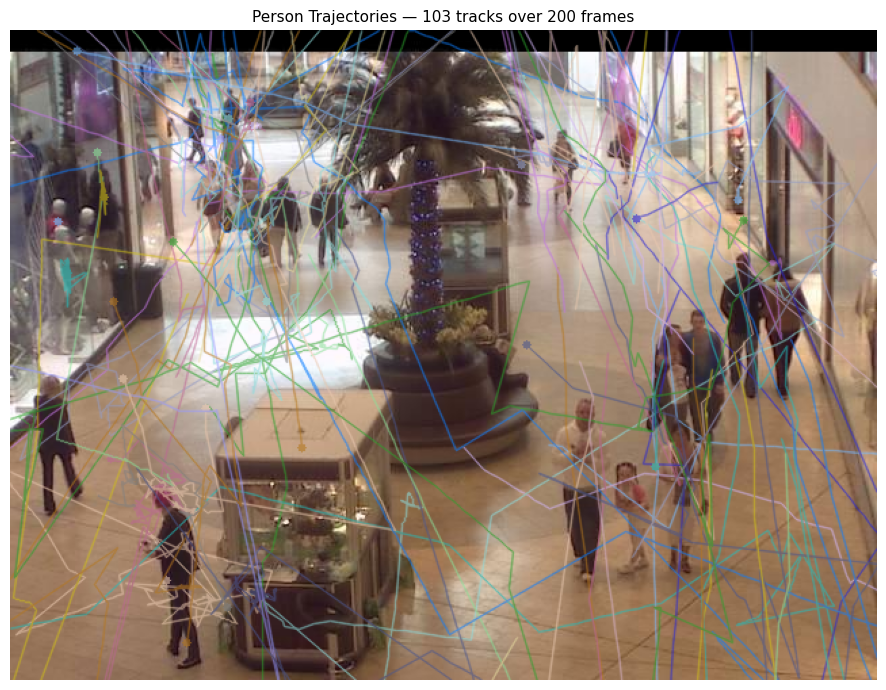

Saved: trajectories.png


In [ ]:
# Draw all trajectories as coloured lines on a single frame (frame 200)
base_img = cv2.imread(str(frame_path(200)))
overlay = base_img.copy()

for tid, points in trajectories_final.items():
    if len(points) < 3:
        continue
    rgba = plt.cm.tab20(int(tid) % 20)
    colour = (int(rgba[0] * 255), int(rgba[1] * 255), int(rgba[2] * 255))
    pts = [(int(cx), int(cy)) for _, cx, cy in points]
    for i in range(1, len(pts)):
        cv2.line(overlay, pts[i - 1], pts[i], colour, 1, cv2.LINE_AA)
    cv2.circle(overlay, pts[-1], 3, colour, -1)

combined = cv2.addWeighted(base_img, 0.4, overlay, 0.6, 0)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
plt.title(f'Person Trajectories — {len(trajectories_final)} tracks over 200 frames', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.savefig(DRIVE_DIR / 'trajectories.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: trajectories.png')

In [ ]:
# Save trajectories as JSON for use in Epic 3 (zone analytics)
trajectories_serialisable = {
    str(tid): [
        {'frame': int(f), 'cx': round(cx, 2), 'cy': round(cy, 2)}
        for f, cx, cy in points
    ]
    for tid, points in trajectories_final.items()
}

JSON_OUT = DRIVE_DIR / 'trajectories.json'
with open(JSON_OUT, 'w') as f:
    json.dump({
        'meta': {
            'frames': len(FRAMES_200),
            'unique_track_ids': unique_ids_final,
            'best_max_age': BEST_MAX_AGE,
            'best_n_init': BEST_N_INIT,
            'conf_threshold': BEST_CONF,
        },
        'trajectories': trajectories_serialisable,
    }, f, indent=2)

print(f'Saved: {JSON_OUT}')
print(f'Tracks in JSON: {len(trajectories_serialisable)}')

Saved: /content/drive/MyDrive/shoplens/trajectories.json
Tracks in JSON: 103
